**MUST INSTALL FIRST**

In [43]:
# Install necessary libraries
%pip install trino
%pip install minio
%pip install matplotlib
%pip install seaborn
%pip install numpy
%pip install prophet
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 5.0 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 4.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1. Import libraries

In [ ]:
# Import necessary libraries
from trino.dbapi import connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import itertools
import os
import json
import pickle
from datetime import datetime
from minio import Minio

## 2. Data Loading

In [25]:
# Establish connection to Trino
conn = connect(
    host="localhost",
    port=8090,
    user="admin",
    catalog="iceberg",
    schema="gold"
)


In [26]:
# Check available tables in the connected schema
pd.read_sql(
    "SHOW TABLES",
    conn
)

C:\Users\PC\AppData\Local\Temp\ipykernel_18784\933403738.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(


,Table
0,dim_customers
1,dim_date
2,dim_employees
3,dim_products
4,fact_sales
5,wide_sales_forecast


In [27]:
# Query to fetch sales data for EDA
query = """
SELECT
    sale_date,
    SUM(total_revenue) AS total_revenue
FROM iceberg.gold.wide_sales_forecast
GROUP BY sale_date
ORDER BY sale_date
"""

df = pd.read_sql(query, conn)

df.head()

C:\Users\PC\AppData\Local\Temp\ipykernel_18784\1676894238.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,sale_date,total_revenue
0,1996-01-01,0.0
1,1996-01-02,0.0
2,1996-01-03,0.0
3,1996-01-04,0.0
4,1996-01-05,0.0


In [28]:
# Find actual sales period

sales_period = df.loc[df["total_revenue"] > 0, "sale_date"]

first_sale_date = sales_period.min()
last_sale_date = sales_period.max()

print(f"First sale date: {first_sale_date}")
print(f"Last sale date : {last_sale_date}")

First sale date: 1996-07-04
Last sale date : 1998-05-06


In [29]:
# Keep only actual business period
df = df[
    (df["sale_date"] >= first_sale_date)
    & (df["sale_date"] <= last_sale_date)
].copy()

print(f"Remaining observations: {len(df)}")

Remaining observations: 672


**Actual Sales Period Identification**

- **Initial inspection** of the daily revenue series revealed extended periods of consecutive **zero-revenue days** at both the beginning and end of the dataset.
- The **first recorded sale** occurred on **1996-07-04**, while the **last recorded sale** occurred on **1998-05-06**.
- This suggests that the Gold layer was generated using a **complete calendar date dimension**, which introduced dates outside the actual transaction period.
- To prevent artificial zero-revenue observations from biasing the forecasting model, the dataset was **restricted to the actual sales period (1996-07-04 to 1998-05-06)**.
- As a result, all subsequent **EDA and forecasting analyses** were performed only on valid business activity data.

In [30]:
# Check for missing dates in the sales period
print(df["sale_date"].min())
print(df["sale_date"].max())
print(df.shape)

1996-07-04
1998-05-06
(672, 2)


## 3. Exploratory Data Analysis

### 3.1. Basic Info

In [31]:
# Check for missing values
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 672 entries, 185 to 856
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_date      672 non-null    object 
 1   total_revenue  672 non-null    float64
dtypes: float64(1), object(1)
memory usage: 15.8+ KB


,total_revenue
count,672.000000
mean,1883.620593
std,2717.602317
min,0.000000
25%,0.000000
50%,1089.600000
75%,2668.752499
max,27143.849995


- **672 daily records** with a continuous time series and **no missing values**.
- **Average daily revenue:** 1,883.62; **median revenue** is lower than the mean, indicating a **right-skewed distribution**.
- Approximately **25% of days recorded zero revenue**, suggesting intermittent low-activity periods.
- **Maximum daily revenue** reached **27,143.85**, indicating the presence of potential outliers.
- The dataset is suitable for modeling **trend** and **weekly seasonality**, but its relatively short time span limits the analysis of **yearly seasonality**.

### 3.2. Missing Dates

In [32]:
# Check for missing dates in the sales period
all_dates = pd.date_range(
    start=df.sale_date.min(),
    end=df.sale_date.max(),
    freq="D"
)

missing_dates = all_dates.difference(df.sale_date)

print("Missing dates:", len(missing_dates))

Missing dates: 0


It forms a continuous time series

### 3.3. Revenue Trend Findings

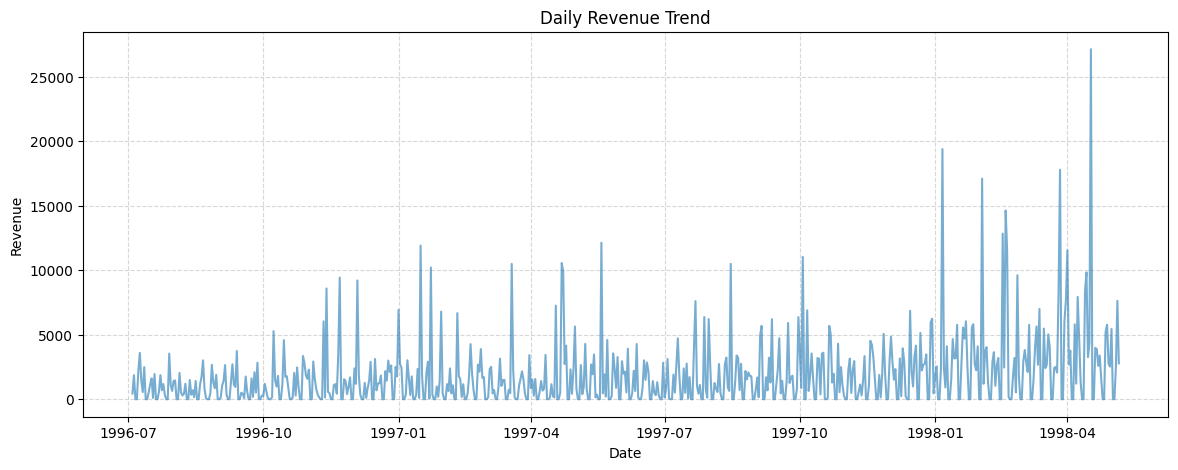

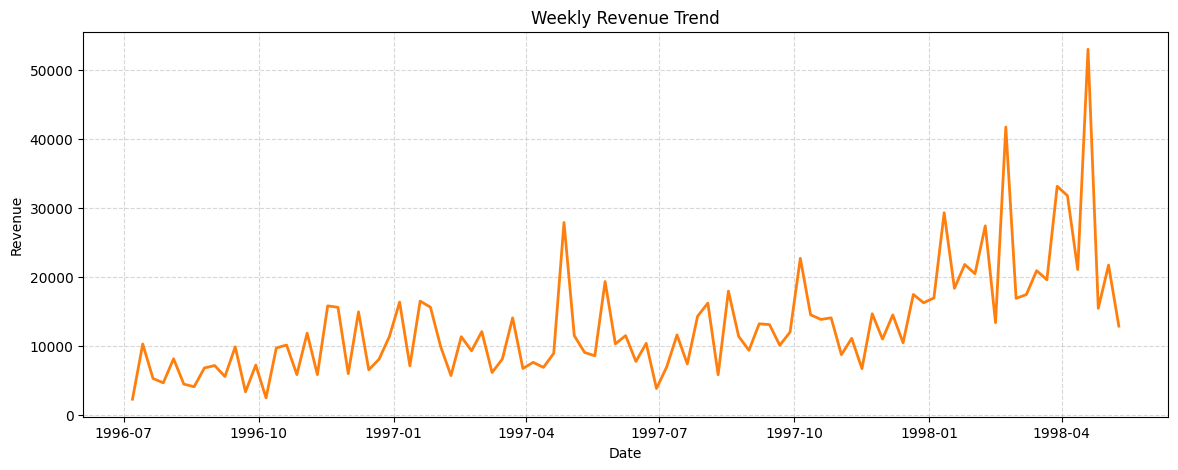

C:\Users\PC\AppData\Local\Temp\ipykernel_18784\3176377449.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index("sale_date").resample("M").sum(numeric_only=True)


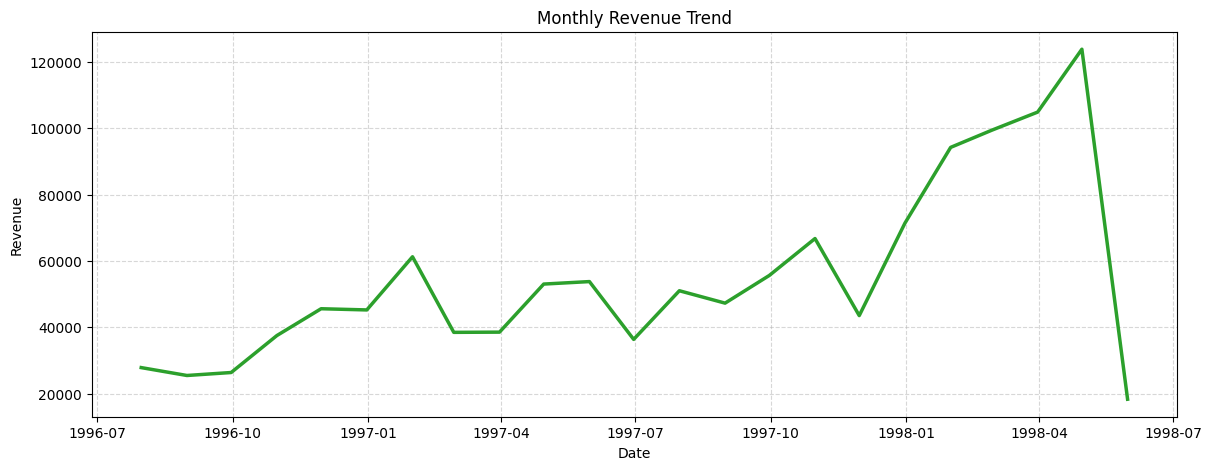

In [33]:
# Convert sale_date to datetime
df["sale_date"] = pd.to_datetime(df["sale_date"])

# Daily Revenue
plt.figure(figsize=(14, 5))
plt.plot(df["sale_date"], df["total_revenue"], color='#1f77b4', alpha=0.6)
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Weekly Revenue
weekly = df.set_index("sale_date").resample("W").sum(numeric_only=True)
plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly["total_revenue"], color='#ff7f0e', linewidth=2)
plt.title("Weekly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Monthly Revenue
monthly = df.set_index("sale_date").resample("M").sum(numeric_only=True)
plt.figure(figsize=(14, 5))
plt.plot(monthly.index, monthly["total_revenue"], color='#2ca02c', linewidth=2.5)
plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

* **Overall Trend:** Revenue exhibits a clear **upward long-term trend**. Performance remained relatively stable from **Jul 1996 to Jun 1997**, followed by a period of strong growth from **Jul 1997 to May 1998**, during which revenue consistently reached new highs.

* **Volatility:** Daily revenue is highly volatile, partly driven by substantial day-to-day fluctuations and the presence of **zero-revenue days (~25% of observations)**. Weekly and monthly aggregations smooth short-term noise and reveal the underlying trend more clearly.

* **Seasonality:** Monthly revenue shows a noticeable decline during **Oct–Nov 1997**, followed by a strong recovery toward the end of the year. This recurring pattern suggests the presence of seasonality, supporting the inclusion of seasonal components in the forecasting model.

### 3.4. Boxplot Outlier

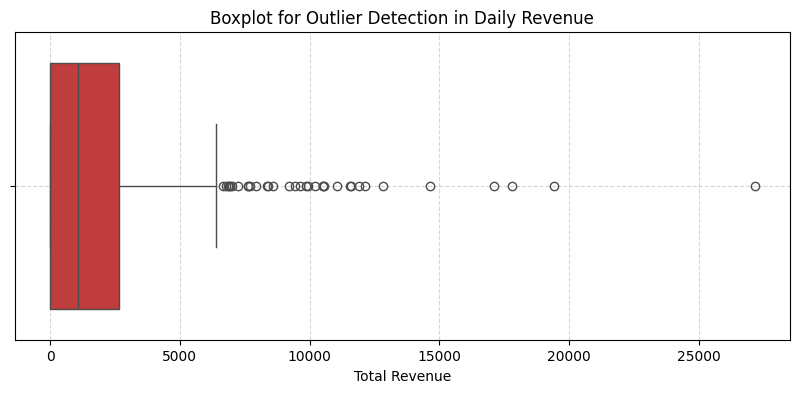

Upper Bound for Outlier Detection: 6671.88
Total Number of Outlier Days: 34
Percentage of Outliers in the Dataset: 5.06%


In [34]:
# Check for outliers in daily revenue
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["total_revenue"], color='#d62728')
plt.title("Boxplot for Outlier Detection in Daily Revenue")
plt.xlabel("Total Revenue")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Visualize boxplot
Q1 = df["total_revenue"].quantile(0.25)
Q3 = df["total_revenue"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[df["total_revenue"] > upper_bound]
outlier_ratio = len(outliers) / len(df) * 100

print(f"Upper Bound for Outlier Detection: {upper_bound:.2f}")
print(f"Total Number of Outlier Days: {len(outliers)}")
print(f"Percentage of Outliers in the Dataset: {outlier_ratio:.2f}%")

* **Outlier Threshold:** The upper bound was identified at **6,671.88**, with several observations exceeding this level and reaching a peak of nearly **28,000** in daily revenue.

* **Frequency & Business Context:** A total of **34 outlier days** were detected, representing **5.06%** of the dataset. Given their relatively low proportion and plausible business nature (e.g., large deals or peak sales periods), these observations are considered valid rather than data quality issues.

* **Treatment Strategy:** All outliers were **retained** for modeling. Since Prophet is designed to capture trend shifts through **changepoints**, potential overfitting caused by extreme observations will be mitigated during hyperparameter tuning, particularly through adjustment of the **`changepoint_prior_scale`** parameter.

### 3.5. Weekly Seasonality

C:\Users\PC\AppData\Local\Temp\ipykernel_18784\1092161410.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


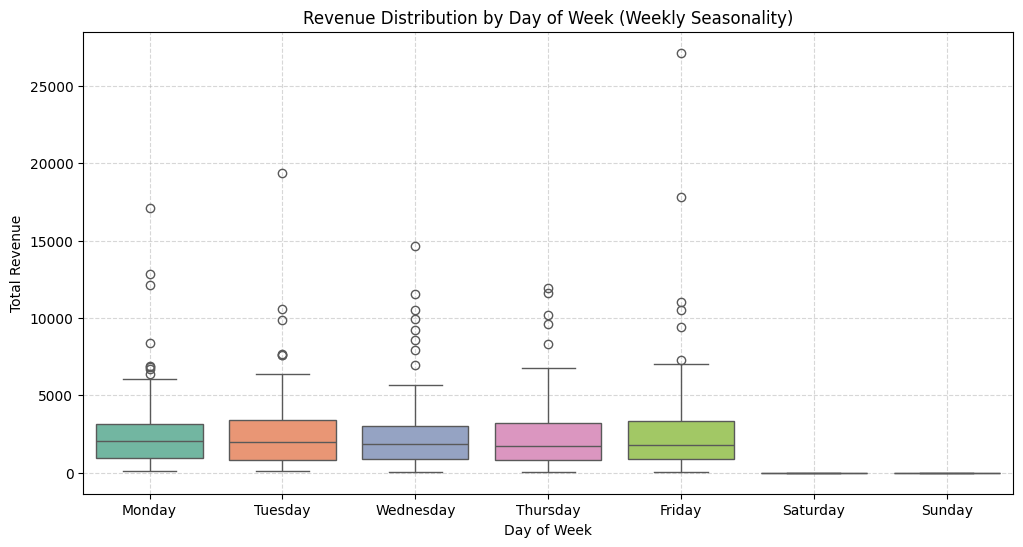

In [35]:
# Add weekday column
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["weekday"] = df["sale_date"].dt.day_name()

# Define the order of weekdays for logical time sequence in the plot
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Visualize boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="weekday",
    y="total_revenue",
    order=weekday_order,
    palette="Set2"  # Thêm màu sắc cho các thứ dễ phân biệt
)

plt.title("Revenue Distribution by Day of Week (Weekly Seasonality)")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

* **Weekday Pattern (Mon–Fri):** Revenue distributions are relatively consistent across weekdays, with similar medians and variability. A considerable number of high-revenue outliers are observed throughout the workweek, indicating occasional sales spikes.

* **Weekend Pattern (Sat–Sun):** Revenue drops significantly during weekends, with much lower revenue levels and fewer extreme values compared to weekdays. This suggests reduced business activity toward the end of the week.

* **Implications for Forecasting:** Strong **weekly seasonality** is clearly present, reflecting systematic differences between weekdays and weekends. Therefore, enabling Prophet's built-in **weekly seasonality component (`weekly_seasonality=True`)** is essential for capturing these recurring patterns and improving forecast accuracy.


### 3.6. Rolling Mean

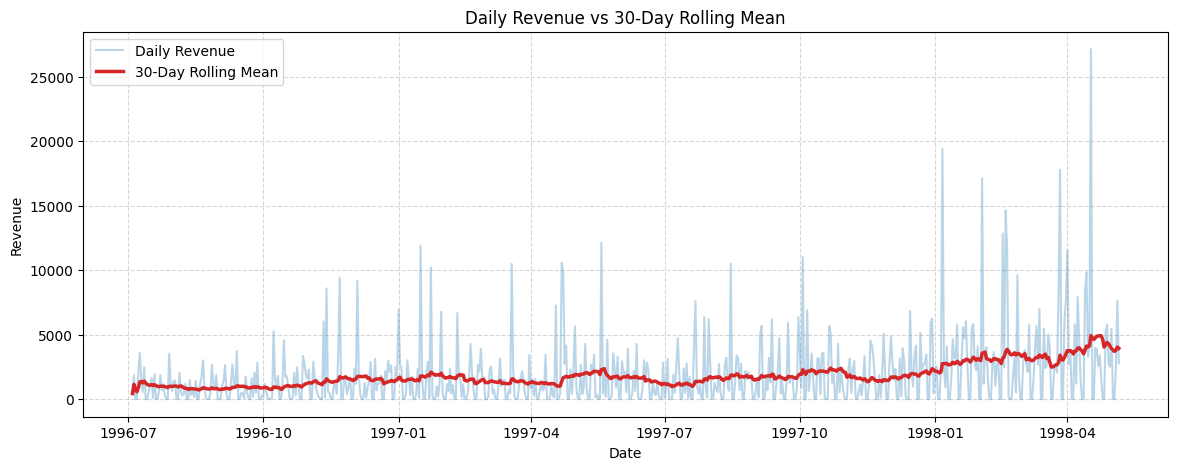

In [36]:
# Add rolling mean for trend analysis

df["rolling_30"] = df["total_revenue"].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(14, 5))

plt.plot(df["sale_date"], df["total_revenue"], color="#1f77b4", alpha=0.3, label="Daily Revenue")

plt.plot(df["sale_date"], df["rolling_30"], color="#d62728", linewidth=2.5, label="30-Day Rolling Mean")

plt.title("Daily Revenue vs 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

* **Noise Reduction:** The **30-day rolling mean** effectively smooths daily fluctuations and weekly effects, revealing the underlying revenue trend more clearly.

* **Trend Dynamics:** The rolling mean highlights two distinct business phases:

  * **Jul 1996 – Jul 1997:** A relatively stable period with revenue fluctuating around a low average level.
  * **Jul 1997 – May 1998:** A pronounced upward trend, indicating sustained business growth and progressively higher revenue levels through the end of the observation period.

* **Implications for Forecasting:** The presence of a clear long-term upward trend supports the use of Prophet's trend component to model the evolving revenue trajectory over time.


### 3.7. EDA Findings & Modeling Insights

The exploratory data analysis revealed several key patterns that directly inform the forecasting strategy:

* **Strong Long-Term Trend:** Revenue exhibits a clear upward trajectory, with a noticeable structural shift around mid-1997. After an initially stable period, the business entered a phase of sustained and rapid growth.

* **Pronounced Weekly Seasonality:** Revenue patterns differ substantially between weekdays and weekends, indicating strong weekly seasonality. Therefore, enabling Prophet's **weekly seasonality component** is essential for capturing recurring operational behavior.

* **Recurring Revenue Cycles:** Monthly and rolling-mean analyses suggest periods of accelerated growth toward the end and beginning of the year, separated by a temporary revenue slowdown around October–November. These recurring fluctuations indicate the presence of seasonal effects that should be considered during modeling.

* **Outlier Handling:** A total of **34 outlier days (5.06% of observations)** exceeded the upper threshold of **6,671.88**, with peak daily revenue approaching **27,000**. These observations were retained because they represent legitimate business events rather than data errors. Their influence will be managed through Prophet's hyperparameter tuning process, particularly the **`changepoint_prior_scale`** parameter.


## 4. Training Prophet

### 4.1. Baseline Model

In [37]:
# Baseline Model with Prophet

# Prepare Data
prophet_df = df[['sale_date', 'total_revenue']].rename(columns={'sale_date': 'ds', 'total_revenue': 'y'})
prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)

# Train/Test Split (80% / 20%)
train_size = int(len(prophet_df) * 0.80)
train_df = prophet_df.iloc[:train_size].copy()
test_df = prophet_df.iloc[train_size:].copy()

# Initialize Baseline Model (Tắt mùa vụ năm theo thiết kế ban đầu)
model = Prophet(
    yearly_seasonality=False, 
    weekly_seasonality=True, 
    daily_seasonality=False)
model.fit(train_df)
print("[INFO] Baseline Prophet model trained successfully!")

21:45:40 - cmdstanpy - INFO - Chain [1] start processing
21:45:40 - cmdstanpy - INFO - Chain [1] done processing


[INFO] Baseline Prophet model trained successfully!


### 4.2. Evaluation & Criteria Check

In [38]:
# Model Evaluation & Criteria Check

future_test = test_df[['ds']].copy()
forecast_test = model.predict(future_test)

# Calculate evaluation metrics
y_true = test_df['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Business acceptance criterion
mean_y_test = np.mean(y_true)
business_threshold = 0.30 * mean_y_test
error_rate = (mae / mean_y_test) * 100

print("=========================================")
print("        BASELINE MODEL EVALUATION        ")
print("=========================================")
print(f"Average Actual Revenue (Test Set) : {mean_y_test:.2f}")
print(f"Target Error Threshold (30% Mean) : {business_threshold:.2f}")
print(f"Model Error (MAE)                 : {mae:.2f}")
print(f"Relative Error Rate               : {error_rate:.2f}%")
print("-----------------------------------------")

if mae <= business_threshold:
    print("[BUSINESS VERDICT]: The baseline model MEETS the predefined performance criterion.")
else:
    print("[BUSINESS VERDICT]: The baseline model DOES NOT MEET the predefined performance criterion.")

        BASELINE MODEL EVALUATION        
Average Actual Revenue (Test Set) : 3440.16
Target Error Threshold (30% Mean) : 1032.05
Model Error (MAE)                 : 2067.98
Relative Error Rate               : 60.11%
-----------------------------------------
[BUSINESS VERDICT]: The baseline model DOES NOT MEET the predefined performance criterion.


#### Interpretation of Results & Next Steps

* **Why is the error rate relatively high (~60%)?** The dataset consists of **daily revenue observations**, which exhibit substantial day-to-day variability and include a large proportion of **zero-revenue days (~25%)**. Such characteristics increase forecasting difficulty and naturally lead to higher prediction errors in a baseline time-series model.

* **Model Limitations:** The baseline Prophet model was configured with **`yearly_seasonality=False`**. However, EDA revealed a strong growth pattern and recurring revenue fluctuations over time. Without a yearly seasonal component, the model may fail to capture longer-term dynamics, resulting in systematic underestimation during periods of rapid growth.

* **Next Steps:** To improve forecasting accuracy, the next phase will focus on **hyperparameter tuning**, including optimization of trend flexibility and seasonal settings. Additional experiments with Prophet's seasonal components, particularly **yearly seasonality**, will be conducted to better capture underlying business patterns and reduce forecasting error.


### 4.3. Hyperparameter Tuning

In [39]:
# Hyperparameter Tuning (Grid Search)

param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.3, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 5.0]
}

all_params = [
    dict(zip(param_grid.keys(), v))
    for v in itertools.product(*param_grid.values())
]

best_mae = float('inf')
best_params = None

for params in all_params:

    model_tuned = Prophet(
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    model_tuned.fit(train_df)

    forecast_test = model_tuned.predict(future_test)

    current_mae = mean_absolute_error(
        y_true,
        forecast_test['yhat'].values
    )

    if current_mae < best_mae:
        best_mae = current_mae
        best_params = params

print("\n=========================================")
print("      HYPERPARAMETER TUNING RESULTS      ")
print("=========================================")
print(f"Best Parameters : {best_params}")
print(f"Best MAE        : {best_mae:.2f}")
print("=========================================")

21:45:40 - cmdstanpy - INFO - Chain [1] start processing
21:45:40 - cmdstanpy - INFO - Chain [1] done processing
21:45:40 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:45:40 - cmdstanpy - INFO - Chain [1] start processing
21:45:40 - cmdstanpy - INFO - Chain [1] done processing
21:45:41 - cmdstanpy - INFO - Chain [1] start processing
21:45:41 - cmdstanpy - INFO - Chain [1] done processing
21:45:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:45:41 - cmdstanpy - INFO - Chain [1] start processing
21:45:41 - cmdstanpy - INFO - Chain [1] done processing
21:45:41 - cmdstanpy - INFO - Chain [1] start processing
21:45:41 - cmdstanpy - INFO - Chain [1] done processing
21:45:41 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
21:45:41 - c


      HYPERPARAMETER TUNING RESULTS      
Best Parameters : {'changepoint_prior_scale': 0.3, 'seasonality_prior_scale': 1.0}
Best MAE        : 2065.41


#### Hyperparameter Tuning Insights

The optimal configuration was obtained with **`changepoint_prior_scale = 0.3`** and **`seasonality_prior_scale = 1.0`**, resulting in the lowest MAE of **2,065.41**.

* **`changepoint_prior_scale = 0.3`** indicates that the model benefits from a relatively flexible trend component. This finding is consistent with the EDA results, which revealed a structural shift in revenue growth around mid-1997. A higher changepoint prior allows Prophet to adapt more effectively to changes in the underlying business trend.

* **`seasonality_prior_scale = 1.0`** suggests that weekly seasonal patterns are important but should not dominate the forecasting process. This level of regularization enables the model to capture recurring weekly behavior while avoiding excessive sensitivity to short-term fluctuations.

* The tuning results confirm that both **trend flexibility** and **seasonality strength** play important roles in modeling the revenue series, which exhibits strong growth dynamics and pronounced weekly seasonality.


### 4.4. Forecast 30 Days

21:45:46 - cmdstanpy - INFO - Chain [1] start processing
21:45:46 - cmdstanpy - INFO - Chain [1] done processing


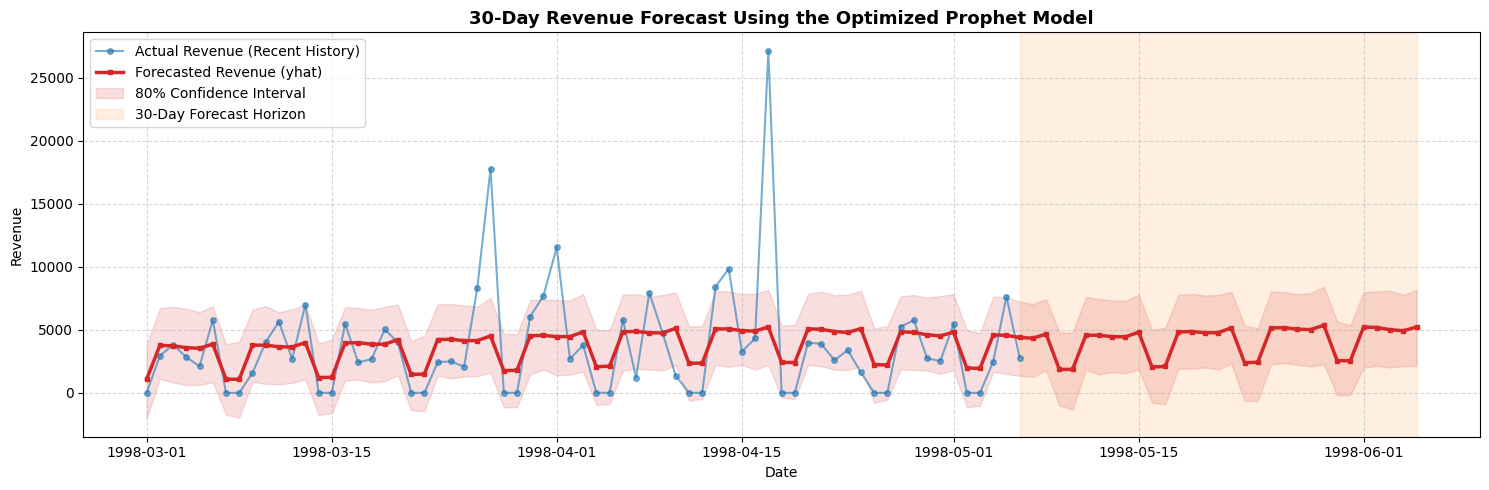

In [ ]:
# Retrain the model on the full dataset using the best hyperparameters
final_model = Prophet(
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    yearly_seasonality=True,   # Enabled to capture longer-term seasonal patterns
    weekly_seasonality=True,
    daily_seasonality=False
)

final_model.fit(prophet_df)

# Generate a 30-day future forecast
future_30 = final_model.make_future_dataframe(periods=30, freq='D')
forecast_30 = final_model.predict(future_30)

# Create a zoomed-in visualization for recent history and future forecasts
zoom_start_date = "1998-03-01"

df_hist_zoom = prophet_df[prophet_df['ds'] >= zoom_start_date]
forecast_zoom = forecast_30[forecast_30['ds'] >= zoom_start_date]

plt.figure(figsize=(15, 5), dpi=100)

plt.plot(
    df_hist_zoom['ds'],
    df_hist_zoom['y'],
    color='#1f77b4',
    marker='o',
    markersize=4,
    alpha=0.6,
    label='Actual Revenue (Recent History)'
)

plt.plot(
    forecast_zoom['ds'],
    forecast_zoom['yhat'],
    color='#d62728',
    linewidth=2.5,
    marker='s',
    markersize=3,
    label='Forecasted Revenue (yhat)'
)

plt.fill_between(
    forecast_zoom['ds'],
    forecast_zoom['yhat_lower'],
    forecast_zoom['yhat_upper'],
    color='#d62728',
    alpha=0.15,
    label='80% Confidence Interval'
)

# Highlight the 30-day forecast horizon
plt.axvspan(
    prophet_df['ds'].max(),
    forecast_zoom['ds'].max(),
    color='#ff7f0e',
    alpha=0.12,
    label='30-Day Forecast Horizon'
)

plt.title(
    "30-Day Revenue Forecast Using the Optimized Prophet Model",
    fontsize=13,
    fontweight='bold'
)

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 5. Model Deployment & Persistence

### 5.1. Model Persistence

In [ ]:
# Path to save model and metrics
MODEL_DIR = "../models/prophet"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save model
model_path = f"{MODEL_DIR}/prophet_v1.pkl"

with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

# Save metrics
metrics = {
    "model_name": "prophet_v1",
    "mae": float(best_mae),
    "rmse": float(rmse),
    "train_end_date": str(prophet_df["ds"].max().date()),
    "trained_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

metrics_path = f"{MODEL_DIR}/prophet_v1_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("[INFO] Model and metrics saved successfully.")
print(f"Model   : {model_path}")
print(f"Metrics : {metrics_path}")

[INFO] Model and metrics saved successfully.
Model   : ../models/prophet/prophet_v1.pkl
Metrics : ../models/prophet/prophet_v1_metrics.json


### 5.2. MinIO Deployment

In [ ]:
# MinIO Deployment

client = Minio(
    "localhost:9000",
    access_key="admin",
    secret_key="admin123",
    secure=False
)

bucket_name = "warehouse"

# Upload model
client.fput_object(
    bucket_name,
    "models/prophet_v1.pkl",
    model_path
)

# Upload metrics
client.fput_object(
    bucket_name,
    "models/prophet_v1_metrics.json",
    metrics_path
)

print("[INFO] Files uploaded to MinIO successfully.")

[INFO] Files uploaded to MinIO successfully.


### 5.3. Deployment Validation

In [ ]:
# Validation Test: Download the model and make a test prediction

download_path = "../models/prophet/prophet_v1_downloaded.pkl"

client.fget_object(
    bucket_name,
    "models/prophet_v1.pkl",
    download_path
)

with open(download_path, "rb") as f:
    loaded_model = pickle.load(f)

future_test_validation = loaded_model.make_future_dataframe(
    periods=5,
    freq="D"
)

validation_forecast = loaded_model.predict(
    future_test_validation
)

print("[SUCCESS] Model downloaded and loaded successfully.")
print(validation_forecast[['ds', 'yhat']].tail())

[SUCCESS] Model downloaded and loaded successfully.
            ds         yhat
672 1998-05-07  4336.461171
673 1998-05-08  4663.092387
674 1998-05-09  1857.653562
675 1998-05-10  1861.968510
676 1998-05-11  4567.477375
